# Check paths

In [1]:
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT"))
print(PROJECT_ROOT)
print(PROJECT_ROOT.is_dir())


DATA_DIR = Path(os.getenv("DATA_DIR"))
print(DATA_DIR)
print(DATA_DIR.is_dir())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests
True
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/data
True


In [2]:
model_ready_data = DATA_DIR / "03_model_ready_presplit" / "ess_model_ready_v1.csv"
model_ready_data.is_file()

True

# features

![frontend_feats](frontend_feats.png)

In [3]:
# Core variables according to ESS documentation:
    #  - etfruit  : frequency of fruit consumption
    #  - eatveg   : frequency of vegetable consumption
    #  - cgtsmok  : smoking behavior
    #  - alcfreq  : alcohol consumption frequency
    #  - slprl    : sleep problems
    #  - paccnois : exposure to noise
    #  - bmi      : body mass index (newly created)
    #  - gndr     : gender
    #  - health   : self-rated health
    #  - dosprt   : sport/physical activity

# Additionally included:
    #  - sclmeet  : frequency of social meetings
    #  - inprdsc  : perceived discrimination
    #  - ctrlife  : perceived control over life

In [4]:
columns_not_in_frontend = [
    "sclmeet",  # frequency of social meetings
    "inprdsc",  # perceived discrimination
    "ctrlife",  # perceived control over life
    "health",   # self-estimated health
]

# load data

In [5]:
import pandas as pd

ess_df = pd.read_csv(model_ready_data)

In [6]:
ess_df

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,health,dosprt,sclmeet,inprdsc,ctrlife,hltprhc,hltprhb,hltprdi
0,3.0,3.0,4.0,3.0,1.0,0,28.405504,1,3.0,3.0,4.0,1.0,8.0,0,1,0
1,1.0,1.0,5.0,3.0,3.0,0,26.218821,2,2.0,5.0,7.0,4.0,8.0,1,0,0
2,4.0,3.0,1.0,4.0,3.0,0,29.320988,2,1.0,3.0,4.0,4.0,9.0,0,0,0
3,2.0,2.0,6.0,7.0,3.0,0,25.099502,2,3.0,3.0,6.0,3.0,8.0,0,1,1
4,3.0,3.0,1.0,2.0,1.0,0,23.738662,1,2.0,3.0,5.0,4.0,9.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41099,2.0,2.0,4.0,5.0,2.0,0,20.202020,2,3.0,0.0,4.0,1.0,9.0,0,0,0
41100,3.0,3.0,6.0,5.0,3.0,0,21.477087,2,3.0,3.0,6.0,2.0,9.0,1,1,0
41101,3.0,2.0,6.0,5.0,1.0,0,28.734672,1,2.0,0.0,4.0,2.0,7.0,0,0,0
41102,3.0,3.0,6.0,5.0,2.0,0,24.609375,2,2.0,1.0,6.0,6.0,10.0,0,0,0


In [7]:
ess_dropped = ess_df.drop(columns=columns_not_in_frontend)
ess_dropped = ess_dropped.drop(columns=["hltprdi"])
ess_dropped

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhc,hltprhb
0,3.0,3.0,4.0,3.0,1.0,0,28.405504,1,3.0,0,1
1,1.0,1.0,5.0,3.0,3.0,0,26.218821,2,5.0,1,0
2,4.0,3.0,1.0,4.0,3.0,0,29.320988,2,3.0,0,0
3,2.0,2.0,6.0,7.0,3.0,0,25.099502,2,3.0,0,1
4,3.0,3.0,1.0,2.0,1.0,0,23.738662,1,3.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
41099,2.0,2.0,4.0,5.0,2.0,0,20.202020,2,0.0,0,0
41100,3.0,3.0,6.0,5.0,3.0,0,21.477087,2,3.0,1,1
41101,3.0,2.0,6.0,5.0,1.0,0,28.734672,1,0.0,0,0
41102,3.0,3.0,6.0,5.0,2.0,0,24.609375,2,1.0,0,0


In [8]:
ess_dropped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41104 entries, 0 to 41103
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   etfruit   41104 non-null  float64
 1   eatveg    41104 non-null  float64
 2   cgtsmok   41104 non-null  float64
 3   alcfreq   41104 non-null  float64
 4   slprl     41104 non-null  float64
 5   paccnois  41104 non-null  int64  
 6   bmi       41104 non-null  float64
 7   gndr      41104 non-null  int64  
 8   dosprt    41104 non-null  float64
 9   hltprhc   41104 non-null  int64  
 10  hltprhb   41104 non-null  int64  
dtypes: float64(7), int64(4)
memory usage: 3.4 MB


In [9]:
# after testing we can train the model on the whole Dataset

ess_dropped.to_csv(DATA_DIR / "04_multi_target" / "ess_model_ready_v2_full_unstratified.csv", index=False)

# split csv file to train and test parts

### distribute data based on stratified targets

In [10]:
import pandas as pd

ess_dropped["stratify"] = ess_dropped[["hltprhc", "hltprhb"]].astype(str).agg("_".join, axis=1)
ess_dropped["stratify"]

0        0_1
1        1_0
2        0_0
3        0_1
4        0_0
        ... 
41099    0_0
41100    1_1
41101    0_0
41102    0_0
41103    0_1
Name: stratify, Length: 41104, dtype: object

In [11]:
# Create a combined stratification label by merging the three target columns.
# This allows train_test_split to preserve the distribution of all target
# combinations across both the training and test sets.

# Each row gets a string like "0_1" representing its target pattern.
# This is necessary because train_test_split only accepts ONE stratify column,
# so we encode all targets into a single grouped label.

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    ess_dropped,
    test_size=0.2,
    random_state=42,
    stratify=ess_dropped["stratify"]
)

In [12]:
train_df = train_df.drop(columns=["stratify"])
test_df = test_df.drop(columns=["stratify"])

In [14]:
train_df.shape

(32883, 11)

In [15]:
test_df.shape

(8221, 11)

# checking distribution

In [ ]:
OUTCOMES = ["hltprhb", "hltprhc"]

outcome_labels = {
    "hltprhb": "High Blood Pressure",
    "hltprhc": "Heart Condition"
}

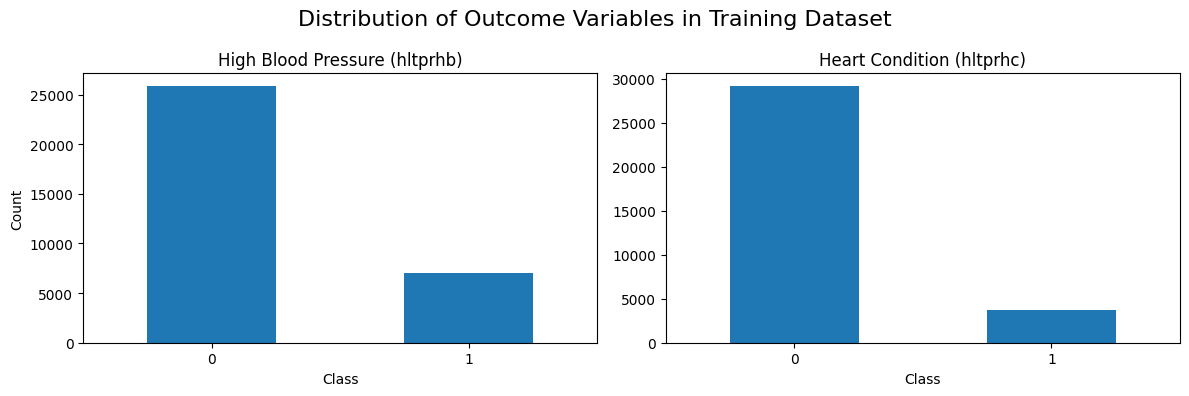

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(OUTCOMES), figsize=(12, 4))

for i, (ax, col) in enumerate(zip(axes, OUTCOMES)):
    train_df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    ax.set_title(f"{outcome_labels[col]} ({col})")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

    # Only leftmost subplot gets a y-label
    if i == 0:
        ax.set_ylabel("Count")
    else:
        ax.set_ylabel("")

fig.suptitle("Distribution of Outcome Variables in Training Dataset", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.tight_layout()
plt.show()


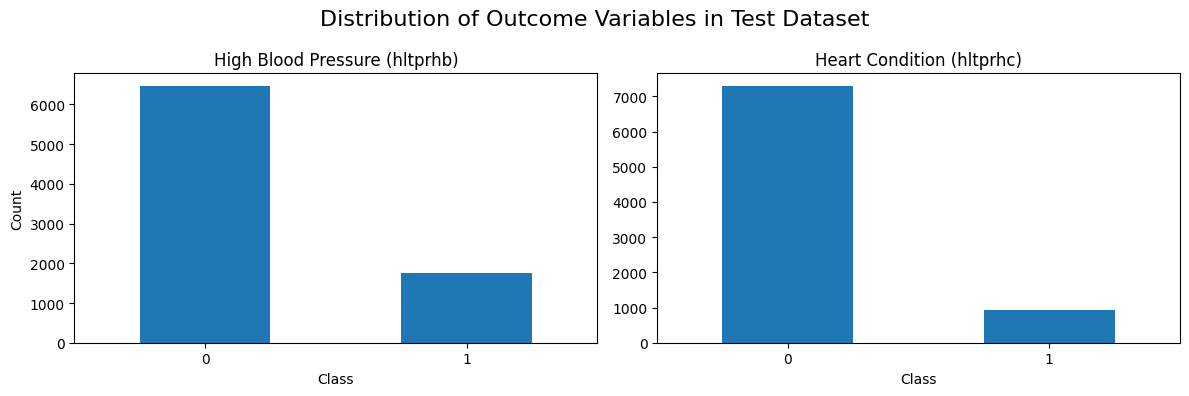

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(OUTCOMES), figsize=(12, 4))

for i, (ax, col) in enumerate(zip(axes, OUTCOMES)):
    test_df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    ax.set_title(f"{outcome_labels[col]} ({col})")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

    if i == 0:
        ax.set_ylabel("Count")
    else:
        ax.set_ylabel("")

fig.suptitle("Distribution of Outcome Variables in Test Dataset", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.tight_layout()
plt.show()


# saving models

# multi-target csv files

In [ ]:
train_df.to_csv(DATA_DIR / "04_multi_target" / "ess_model_ready_v2_train.csv", index=False)
test_df.to_csv(DATA_DIR / "04_multi_target" / "ess_model_ready_v2_test.csv", index=False)

# full single-target csv files

In [ ]:
print(OUTCOMES)

['hltprhb', 'hltprhc']


In [ ]:
for target in OUTCOMES:
    full = ess_dropped.drop(columns=[col for col in OUTCOMES if col != target] + ["stratify"])

    train_df, test_df = train_test_split(
        full,
        test_size=0.2,
        random_state=42,
        stratify=ess_dropped["stratify"]
    )

    full.to_csv(DATA_DIR / "05_single_target" / f"ess_ready_v2_{target}.csv", index=False)
    train_df.to_csv(DATA_DIR / "05_single_target" / f"ess_ready_v2_{target}_train.csv", index=False)
    test_df.to_csv(DATA_DIR / "05_single_target" / f"ess_ready_v2_{target}_test.csv", index=False)
